## *Treinando e Ajustando um Modelo de Classificação (RNA)*
**Objetivo do Projeto:** Selecionar e preparar um dataset de classificação. Treinar uma Rede Neural Artificial do tipo MLP, aplicando técnicas de ajuste de hiperparâmetros e validação cruzada para otimizar o desempenho do modelo.

**Dataset Escolhido:** **kr-vs-kp**
*Descrição: Chess End-Game -- King+Rook versus King+Pawn on a7 (usually abbreviated KRKPA7). The pawn on a7 means it is one square away from queening. It is the King+Rook's side (white) to move.*

**Classificação Almejada:** O modelo será capaz de prever com precisão alta (acima de 95%) se um estado qualquer a partir do estado KRKPA7 representa uma posição de vitória ou derrota para as peças brancas.

* ### *Imports*

In [1]:
from sklearn.datasets import fetch_openml
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import sklearn


from sklearn.preprocessing import OneHotEncoder
print(sklearn.__version__)

1.8.0


In [2]:
dataset = fetch_openml(data_id=3, as_frame=True, parser='auto')

* ### *Dados de entrada e saída*

O dataset já separa nossa variável target (Y) do restante dos dados

In [3]:
X = dataset.data
Y = dataset.target

In [4]:
# Descrição do dataset
dataset.DESCR

'Author: Alen Shapiro\nSource: [UCI](https://archive.ics.uci.edu/ml/datasets/Chess+(King-Rook+vs.+King-Pawn))\nPlease cite: [UCI citation policy](https://archive.ics.uci.edu/ml/citation_policy.html)\n\n1. Title: Chess End-Game -- King+Rook versus King+Pawn on a7\n(usually abbreviated KRKPA7). The pawn on a7 means it is one square\naway from queening. It is the King+Rook\'s side (white) to move.\n\n2. Sources:\n(a) Database originally generated and described by Alen Shapiro.\n(b) Donor/Coder: Rob Holte (holte@uottawa.bitnet). The database\nwas supplied to Holte by Peter Clark of the Turing Institute\nin Glasgow (pete@turing.ac.uk).\n(c) Date: 1 August 1989\n\n3. Past Usage:\n- Alen D. Shapiro (1983,1987), "Structured Induction in Expert Systems",\nAddison-Wesley. This book is based on Shapiro\'s Ph.D. thesis (1983)\nat the University of Edinburgh entitled "The Role of Structured\nInduction in Expert Systems".\n- Stephen Muggleton (1987), "Structuring Knowledge by Asking Questions",\npp.

In [5]:
# O dataset não possui valores ausentes nem inválidos nem duplicados, cada linha é um resultado único de todas as possibilidades
# que a partida de xadrez pode seguir
X.describe()

,bkblk,bknwy,bkon8,bkona,bkspr,bkxbq,bkxcr,bkxwp,blxwp,bxqsq,...,skrxp,spcop,stlmt,thrsk,wkcti,wkna8,wknck,wkovl,wkpos,wtoeg
count,3196,3196,3196,3196,3196,3196,3196,3196,3196,3196,...,3196,3196,3196,3196,3196,3196,3196,3196,3196,3196
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,f,t,t,n
freq,2839,2971,3076,2874,2129,1722,2026,2500,1980,2225,...,3021,3195,3149,3060,2631,3021,1984,2007,2345,2407


In [6]:
# Confirmando que há resultado para todas as possíveis configurações de tabuleiro
# Se houvesse menos que 3196, alguns possíveis estados teriam sido deixados sem resposta de vitória ou derrota
print(Y.size)

3196


In [7]:
# Identificando valores únicos nas colunas para saber qual tipo de encoding será mais adequado
for col in X.columns:
    print(f'{col}: {sorted(X[col].unique())}')

bkblk: ['f', 't']
bknwy: ['f', 't']
bkon8: ['f', 't']
bkona: ['f', 't']
bkspr: ['f', 't']
bkxbq: ['f', 't']
bkxcr: ['f', 't']
bkxwp: ['f', 't']
blxwp: ['f', 't']
bxqsq: ['f', 't']
cntxt: ['f', 't']
dsopp: ['f', 't']
dwipd: ['g', 'l']
hdchk: ['f', 't']
katri: ['b', 'n', 'w']
mulch: ['f', 't']
qxmsq: ['f', 't']
r2ar8: ['f', 't']
reskd: ['f', 't']
reskr: ['f', 't']
rimmx: ['f', 't']
rkxwp: ['f', 't']
rxmsq: ['f', 't']
simpl: ['f', 't']
skach: ['f', 't']
skewr: ['f', 't']
skrxp: ['f', 't']
spcop: ['f', 't']
stlmt: ['f', 't']
thrsk: ['f', 't']
wkcti: ['f', 't']
wkna8: ['f', 't']
wknck: ['f', 't']
wkovl: ['f', 't']
wkpos: ['f', 't']
wtoeg: ['n', 't']


In [8]:
colunas_f_t = []

In [9]:
for col in X.columns:
    if X[col].nunique() < 3 and set(X[col].unique()) <= {'f', 't'}:
        colunas_f_t.append(col)

In [10]:
len(colunas_f_t)

33

In [11]:
[col for col in X.columns if col not in colunas_f_t]

['dwipd', 'katri', 'wtoeg']

In [12]:
for col in ['dwipd', 'katri', 'wtoeg']:
    print(f'{col}: {sorted(X[col].unique())}')

dwipd: ['g', 'l']
katri: ['b', 'n', 'w']
wtoeg: ['n', 't']


In [13]:
## OneHotEncoder (OHE) do scikit: 
# sparse_output=False retorna uma matriz com os 0s bem definidos, se fosse True, retornaria um array do Numpy
# handle_unknown='ignore' evita que o encoding falhe caso o conjunto de treino não tenha todos os dados do conjunto de teste
# set_output(transform='pandas') garante que o output do transform será um DF e não uma série
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform="pandas") 

# Pré-processamento — Encoding das Variáveis Categóricas

Como todos os atributos do dataset são categóricos, é necessário convertê-los para valores numéricos antes de treinar a MLP.

Ao inspecionar os valores únicos de cada coluna, identificamos dois grupos distintos:

- **35 colunas binárias** (`f`/`t`, `g`/`l`, `n`/`t`): possuem apenas dois valores possíveis, sem relação de ordem entre eles. Para essas, basta um mapeamento direto para 0 e 1 com `.replace()`, sem necessidade de criar novas colunas.

- **`katri`**: única coluna com 3 valores (`b`, `n`, `w`), representando qual lado controla uma determinada característica da posição — preto, nenhum ou branco. Como não há ordem entre esses valores, aplicamos o **One-Hot Encoding (OHE)**, que cria uma coluna binária para cada categoria, evitando que o modelo interprete uma relação numérica onde não existe.

In [14]:
X[colunas_f_t] = X[colunas_f_t].astype("str").replace({'f': 0, 't': 1})
X[["dwipd", "wtoeg"]] = X[["dwipd", "wtoeg"]].astype("str").replace({
    'f': 0, 't': 1,
    'n': 0, 
    'g': 1, 'l': 0
})

* ### *Divisão Train-Test-Val*

Dividindo os dados em conjuntos de treino para ensinar ao modelo o comportamento dos dados. Depois em conjuntos para testar se ele aprendeu corretamente e, por fim, conjuntos para validar o aprendizado. 

In [15]:
# treino+val vs teste
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=25, stratify=Y
)

# treino vs validação
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.17, random_state=25, stratify=Y_trainval
)

print("Treino:", X_train.shape, Y_trainval.shape)
print("Val:   ", X_val.shape,   Y_val.shape)
print("Teste: ", X_test.shape,  Y_test.shape)
print(X_trainval.columns)

Treino: (2121, 36) (2556,)
Val:    (435, 36) (435,)
Teste:  (640, 36) (640,)
Index(['bkblk', 'bknwy', 'bkon8', 'bkona', 'bkspr', 'bkxbq', 'bkxcr', 'bkxwp',
       'blxwp', 'bxqsq', 'cntxt', 'dsopp', 'dwipd', 'hdchk', 'katri', 'mulch',
       'qxmsq', 'r2ar8', 'reskd', 'reskr', 'rimmx', 'rkxwp', 'rxmsq', 'simpl',
       'skach', 'skewr', 'skrxp', 'spcop', 'stlmt', 'thrsk', 'wkcti', 'wkna8',
       'wknck', 'wkovl', 'wkpos', 'wtoeg'],
      dtype='str')


* ### Deecodificando dados para iniciar o aprendizado

Utilizamos o One-Hot-Encoder para converter os dados em matrizes de valores numéricos de forma que o modelo "entenda" eles.

In [16]:
# Ajusta (aprende as regras/categorias) APENAS no treino.
# É a forma correta é usar somente o fit() no treino (encoding). 
# Se faz apenas no treino para não vazar respostas dos dados de teste e validação ao modelo. 
# Depois, se usa apenas o transform() (para aplicar o encoding) na validação e no teste.

ohe.fit(X_train[["katri"]])

# 2. Apenas transforma (aplica as regras aprendidas) em todos os conjuntos:
X_train_hot_encoded = ohe.transform(X_train[["katri"]])
X_val_hot_encoded = ohe.transform(X_val[["katri"]])
X_test_hot_encoded = ohe.transform(X_test[["katri"]])

print(type(X_train))
print("Treino:", X_train.shape)
print("Val:   ", X_val_hot_encoded.shape)
print("Teste: ", X_test_hot_encoded.shape)


<class 'pandas.DataFrame'>
Treino: (2121, 36)
Val:    (435, 3)
Teste:  (640, 3)


In [17]:
X_train_concated = pd.concat([X_train.drop(columns="katri"), X_train_hot_encoded], axis=1)
X_val_concated = pd.concat([X_val.drop(columns="katri"), X_val_hot_encoded], axis=1)
X_test_concated = pd.concat([X_test.drop(columns="katri"), X_test_hot_encoded], axis=1)

In [18]:
print("Treino:", X_train_concated.shape)
print("Val:   ", X_val_concated.shape)
print("Teste: ", X_test_concated.shape)

Treino: (2121, 38)
Val:    (435, 38)
Teste:  (640, 38)


* ### Encoder para a Saída 

In [19]:
# Como a saída é binário (cenário de vitória ou derrota para as brancas), não precisamos fazer um encoding tão grande
# Basta aplicar os valores com um map, mantendo o tamanho das séries originais.

Y_train_encoded = Y_train.map({'nowin': 0, 'won': 1})
Y_val_encoded = Y_val.map({'nowin': 0, 'won': 1})
Y_test_encoded = Y_test.map({'nowin': 0, 'won': 1})

print(type(Y_train_encoded))
print("Treino:", Y_train_encoded.shape)
print("Val:   ", Y_val_encoded.shape)
print("Teste: ", Y_test_encoded.shape)

<class 'pandas.Series'>
Treino: (2121,)
Val:    (435,)
Teste:  (640,)


# Treinando a rede

c:\Users\JM\Desktop\ML\2\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JM\Desktop\ML\2\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JM\Desktop\ML\2\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JM\Desktop\ML\2\projeto-ml-basico\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged ye

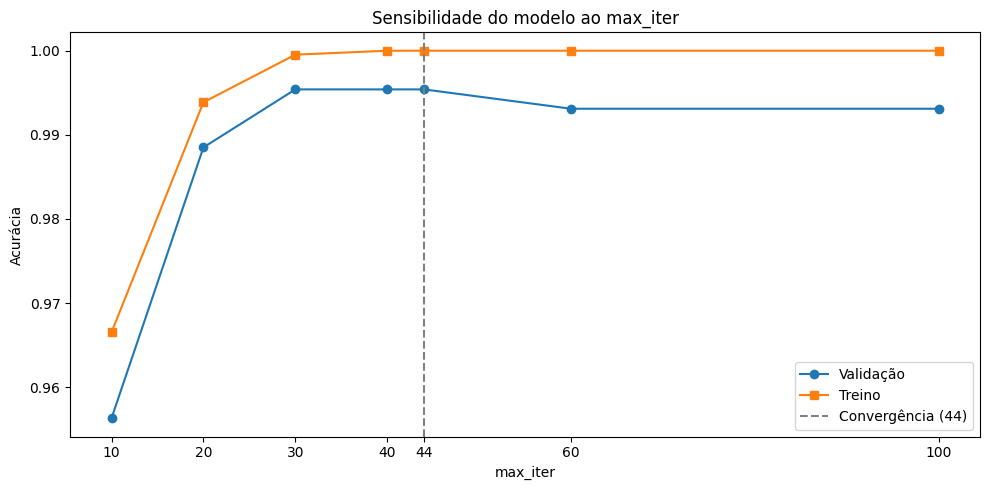

In [161]:
import matplotlib.pyplot as plt
modelos = [
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=10, random_state=69).fit(X_train_concated, Y_train_encoded),
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=20, random_state=69).fit(X_train_concated, Y_train_encoded),
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=30, random_state=69).fit(X_train_concated, Y_train_encoded),
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=40, random_state=69).fit(X_train_concated, Y_train_encoded),
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=44, random_state=69).fit(X_train_concated, Y_train_encoded),
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=60, random_state=69).fit(X_train_concated, Y_train_encoded),
    MLPClassifier(hidden_layer_sizes=(32,)*4, activation="relu", solver="adam", max_iter=100, random_state=69).fit(X_train_concated, Y_train_encoded),
]

iters = [m.max_iter for m in modelos]

acuracias_val = [
    accuracy_score(Y_val_encoded, m.predict(X_val_concated)) for m in modelos
]

acuracias_treino = [
    accuracy_score(Y_train_encoded, m.predict(X_train_concated)) for m in modelos
]

plt.figure(figsize=(10, 5))
plt.plot(iters, acuracias_val, marker='o', label='Validação')
plt.plot(iters, acuracias_treino, marker='s', label='Treino')
plt.axvline(x=44, color='gray', linestyle='--', label='Convergência (44)')
plt.xlabel('max_iter')
plt.ylabel('Acurácia')
plt.title('Sensibilidade do modelo ao max_iter')
plt.legend()
plt.xticks(iters)
plt.tight_layout()
plt.show()

In [164]:
import pandas as pd

dados = {
    'max_iter': [m.max_iter for m in modelos],
    'n_iter_real': [m.n_iter_ for m in modelos],
    'acuracia_treino': [accuracy_score(Y_train_encoded, m.predict(X_train_concated)) for m in modelos],
    'acuracia_val': [accuracy_score(Y_val_encoded, m.predict(X_val_concated)) for m in modelos],
    'perda' : [m.loss_ for m in modelos]
}

df_resultados = pd.DataFrame(dados)
df_resultados

,max_iter,n_iter_real,acuracia_treino,acuracia_val,perda
0,10,10,0.966525,0.956322,0.108600
1,20,20,0.993871,0.988506,0.026424
2,30,30,0.999529,0.995402,0.008627
3,40,40,1.000000,0.995402,0.003205
4,44,44,1.000000,0.995402,0.002222
5,60,60,1.000000,0.993103,0.000967
6,100,78,1.000000,0.993103,0.000452


Podemos observar que a partir de 44 iterações, o modelo converge, após isso temos apenas melhorias no nível de perdas.
A partir de 40 iterações, o treino já memoriza 100%, podemos ver um leve overfitting no treino.